In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
from sklearn.decomposition import PCA
from sklearn.neighbors import KernelDensity
from sklearn.model_selection import GridSearchCV

In [3]:
df=pd.read_csv("mnist_train.csv")
param = {"bandwidth": np.linspace(100,200,30)}
print(param)

{'bandwidth': array([100.        , 103.44827586, 106.89655172, 110.34482759,
       113.79310345, 117.24137931, 120.68965517, 124.13793103,
       127.5862069 , 131.03448276, 134.48275862, 137.93103448,
       141.37931034, 144.82758621, 148.27586207, 151.72413793,
       155.17241379, 158.62068966, 162.06896552, 165.51724138,
       168.96551724, 172.4137931 , 175.86206897, 179.31034483,
       182.75862069, 186.20689655, 189.65517241, 193.10344828,
       196.55172414, 200.        ])}


# plan

##### N<> : DataFrame
##### P<> : PCA
##### T<> : PCA transfrom data
##### G<> : GridSearchCV
##### K<> : KernelDensity
##### S<> : Sample

In [4]:
N0=df[df["label"]==0].drop(columns=["label"])

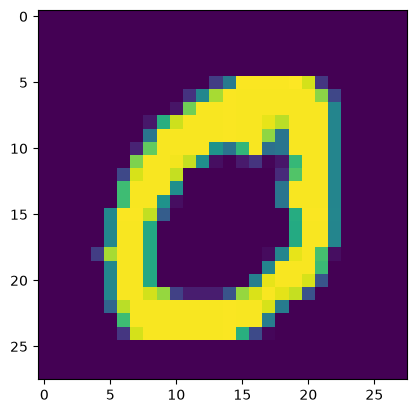

In [5]:
plt.imshow(N0.iloc[4].to_numpy().reshape(28,28))

In [6]:
P0=PCA(15)

In [7]:
T0=P0.fit_transform(N0)

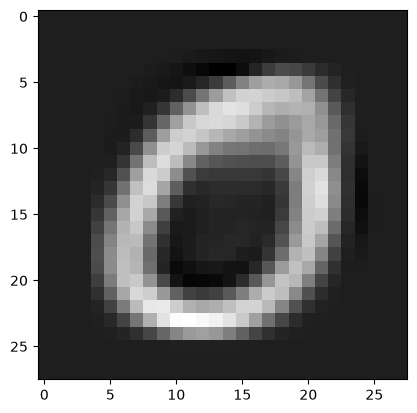

In [8]:
plt.imshow(P0.inverse_transform(T0[4].reshape(1,-1)).reshape(28,28),cmap="gray")

In [9]:
G0 = GridSearchCV(KernelDensity(kernel="gaussian"), param,cv=5,n_jobs=-1)
G0.fit(T0)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KernelDensity()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.",{'bandwidth': array([100. ...200. ])}
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate parameter inde

In [10]:
K0=G0.best_estimator_
S0=K0.sample(100)

In [11]:
print(G0.best_params_)
print(G0.best_score_)

{'bandwidth': np.float64(158.6206896551724)}
-123716.03410432681


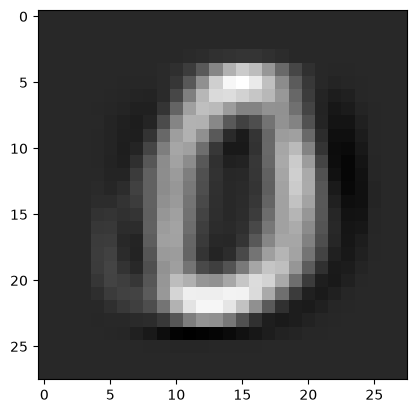

In [12]:
plt.imshow(P0.inverse_transform(S0[50].reshape(1,-1)).reshape(28,28),cmap="gray")

# Model

In [13]:
class Genes:
    def __init__(self,param,n):
        self.pca=PCA(n)
        self.grid=GridSearchCV(KernelDensity(kernel="gaussian"), param,cv=5,n_jobs=-1)
    def fit(self,X):
        T=self.pca.fit_transform(X)
        self.grid.fit(T)
        self.kde=self.grid.best_estimator_
    def sample(self,n):
        S=self.kde.sample(n)
        return self.pca.inverse_transform(S)
    def fil(self,X):
        return np.where(X > X.mean(axis=1, keepdims=True), X, 0)
    def fil_sample(self,n):
        S=self.kde.sample(n)
        S=self.pca.inverse_transform(S)
        return self.fil(S)


In [14]:
G=Genes(param,15)

In [15]:
G.fit(N0)

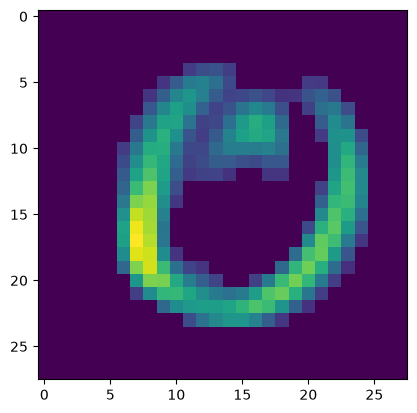

In [16]:
plt.imshow(G.fil_sample(1).reshape(28,28))

In [17]:
%who
del N0,P0,T0,G0,K0,S0,G

G	 G0	 Genes	 GridSearchCV	 K0	 KernelDensity	 N0	 P0	 PCA	 
S0	 T0	 df	 np	 param	 pd	 plt	 


In [18]:
%who

Genes	 GridSearchCV	 KernelDensity	 PCA	 df	 np	 param	 pd	 plt	 



# 0

In [19]:
N0=df[df["label"]==0].drop(columns=["label"])
G0=Genes(param,15)
G0.fit(N0)


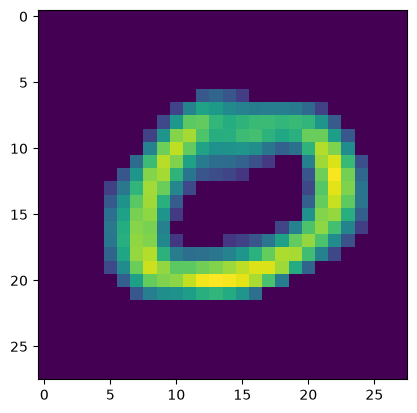

In [20]:
plt.imshow(G0.fil_sample(1).reshape(28,28))

In [21]:
G0.kde.get_params()

{'algorithm': 'auto',
 'atol': 0,
 'bandwidth': np.float64(158.6206896551724),
 'breadth_first': True,
 'kernel': 'gaussian',
 'leaf_size': 40,
 'metric': 'euclidean',
 'metric_params': None,
 'rtol': 0}

# 1

In [22]:
N1=df[df["label"]==1].drop(columns=["label"])
G1=Genes(param,15)
G1.fit(N1)


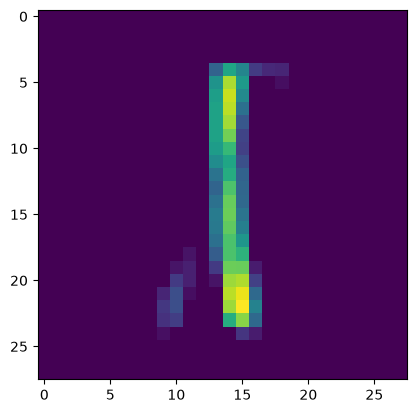

In [23]:
plt.imshow(G1.fil_sample(1).reshape(28,28))

In [24]:
G1.kde.get_params()

{'algorithm': 'auto',
 'atol': 0,
 'bandwidth': np.float64(100.0),
 'breadth_first': True,
 'kernel': 'gaussian',
 'leaf_size': 40,
 'metric': 'euclidean',
 'metric_params': None,
 'rtol': 0}

# 2

In [25]:
N2=df[df["label"]==2].drop(columns=["label"])
G2=Genes(param,15)
G2.fit(N2)

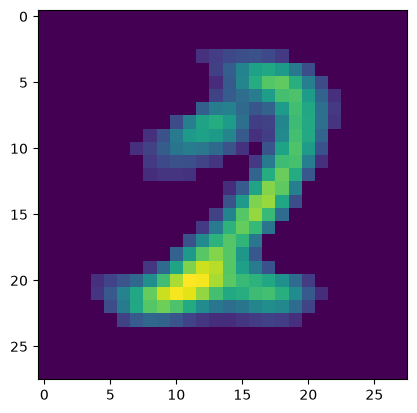

In [26]:
plt.imshow(G2.fil_sample(1).reshape(28,28))

In [27]:
G2.kde.get_params()

{'algorithm': 'auto',
 'atol': 0,
 'bandwidth': np.float64(172.41379310344826),
 'breadth_first': True,
 'kernel': 'gaussian',
 'leaf_size': 40,
 'metric': 'euclidean',
 'metric_params': None,
 'rtol': 0}

# 3

In [28]:
N3=df[df["label"]==3].drop(columns=["label"])
G3=Genes(param,15)
G3.fit(N3)

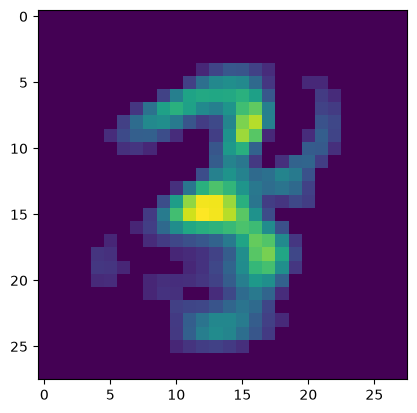

In [29]:
plt.imshow(G3.fil_sample(1).reshape(28,28))

In [30]:
G3.kde.get_params()

{'algorithm': 'auto',
 'atol': 0,
 'bandwidth': np.float64(165.51724137931035),
 'breadth_first': True,
 'kernel': 'gaussian',
 'leaf_size': 40,
 'metric': 'euclidean',
 'metric_params': None,
 'rtol': 0}

# 4

In [31]:
N4=df[df["label"]==4].drop(columns=["label"])
G4=Genes(param,15)
G4.fit(N4)

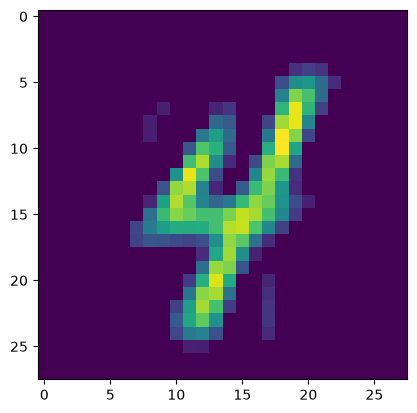

In [32]:
plt.imshow(G4.fil_sample(1).reshape(28,28))

In [33]:
G4.kde.get_params()

{'algorithm': 'auto',
 'atol': 0,
 'bandwidth': np.float64(144.82758620689654),
 'breadth_first': True,
 'kernel': 'gaussian',
 'leaf_size': 40,
 'metric': 'euclidean',
 'metric_params': None,
 'rtol': 0}

# 5

In [34]:
N5=df[df["label"]==5].drop(columns=["label"])
G5=Genes(param,15)
G5.fit(N5)

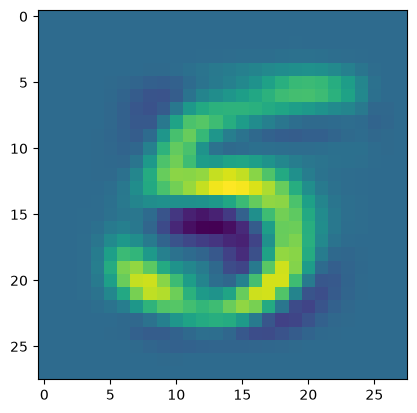

In [35]:
plt.imshow(G5.sample(1).reshape(28,28))

In [36]:
G5.kde.get_params()

{'algorithm': 'auto',
 'atol': 0,
 'bandwidth': np.float64(162.06896551724137),
 'breadth_first': True,
 'kernel': 'gaussian',
 'leaf_size': 40,
 'metric': 'euclidean',
 'metric_params': None,
 'rtol': 0}

# 6

In [37]:
N6=df[df["label"]==6].drop(columns=["label"])
G6=Genes(param,15)
G6.fit(N6)

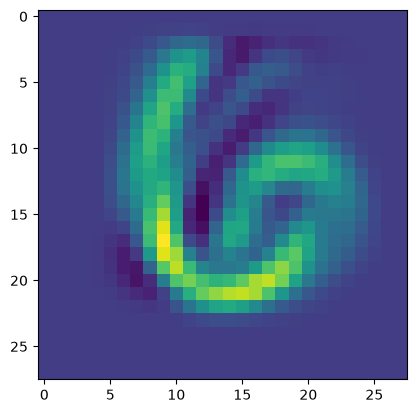

In [38]:
plt.imshow(G6.sample(1).reshape(28,28))

In [39]:
G6.kde.get_params()

{'algorithm': 'auto',
 'atol': 0,
 'bandwidth': np.float64(144.82758620689654),
 'breadth_first': True,
 'kernel': 'gaussian',
 'leaf_size': 40,
 'metric': 'euclidean',
 'metric_params': None,
 'rtol': 0}

# 7

In [40]:
N7=df[df["label"]==7].drop(columns=["label"])
G7=Genes(param,15)
G7.fit(N7)

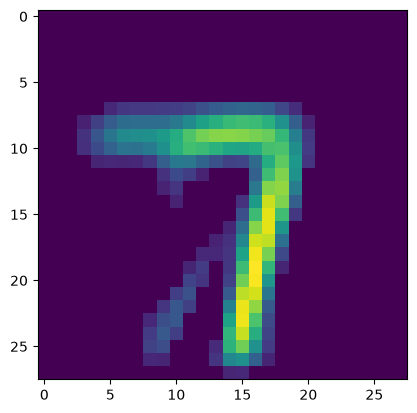

In [41]:
plt.imshow(G7.fil_sample(1).reshape(28,28))

In [42]:
G7.kde.get_params()

{'algorithm': 'auto',
 'atol': 0,
 'bandwidth': np.float64(131.0344827586207),
 'breadth_first': True,
 'kernel': 'gaussian',
 'leaf_size': 40,
 'metric': 'euclidean',
 'metric_params': None,
 'rtol': 0}

# 8

In [43]:
N8=df[df["label"]==8].drop(columns=["label"])
G8=Genes(param,15)
G8.fit(N8)

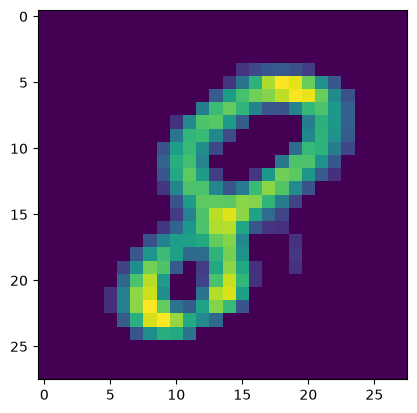

In [44]:
plt.imshow(G8.fil_sample(1).reshape(28,28))

In [45]:
G8.kde.get_params(
)

{'algorithm': 'auto',
 'atol': 0,
 'bandwidth': np.float64(165.51724137931035),
 'breadth_first': True,
 'kernel': 'gaussian',
 'leaf_size': 40,
 'metric': 'euclidean',
 'metric_params': None,
 'rtol': 0}

# 9

In [46]:
N9=df[df["label"]==9].drop(columns=["label"])
G9=Genes(param,15)
G9.fit(N9)

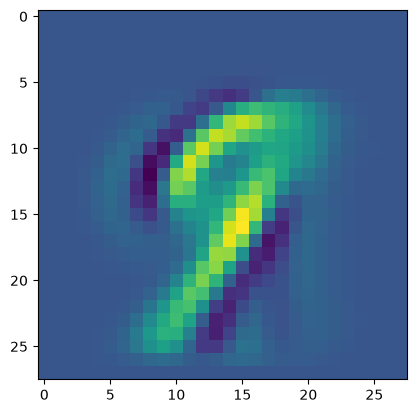

In [47]:
plt.imshow(G9.sample(1).reshape(28,28))

In [48]:
G9.kde.get_params()

{'algorithm': 'auto',
 'atol': 0,
 'bandwidth': np.float64(141.3793103448276),
 'breadth_first': True,
 'kernel': 'gaussian',
 'leaf_size': 40,
 'metric': 'euclidean',
 'metric_params': None,
 'rtol': 0}

In [49]:
G=[G0,G1,G2,G3,G4,G5,G6,G7,G8,G9]

In [50]:
G[0].sample(1)

array([[-1.10024243e-13, -8.26845389e-15,  8.07536768e-14,
         9.13156861e-14,  3.18691525e-14, -5.17841810e-14,
        -4.17769025e-14,  1.70396982e-14,  7.63963654e-15,
        -2.06499170e-14, -5.28865418e-15,  2.34230660e-14,
         5.94891393e-15, -3.18011593e-15,  1.03269828e-15,
         1.14256406e-15, -1.79444615e-17, -6.00330670e-17,
        -2.17304724e-16,  1.56099732e-16,  5.27777298e-17,
        -7.09925499e-17, -1.46269629e-17,  1.24844576e-18,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         1.11103230e-01,  2.19602477e-01,  9.02713740e-02,
         0.00000000e+00,  1.44141541e-01,  3.93986879e-01,
         1.87384003e-01,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+0

In [62]:
class Digiter:
    def __init__(self,gs):
        self.gs=gs
    def gen(self,xs:str):
        xs=str(xs)
        ps=[]
        for i in xs:
            if i.isdigit():
                ps.append(self.gs[int(i)].fil_sample(1).reshape(28,28))
        imag=np.concatenate(ps,axis=1)
        maxv=imag.max()
        minv=imag.min()
        if maxv-minv>0:
            imag_scal = ((imag - minv) / (maxv - minv )) * 253.0
        else : imag_scal=np.zeros_like(imag)

        return imag_scal+1.0
    def cut(self, imag):
        return np.delete(imag,np.where(imag.mean(axis=0)==0),axis=1)
    def gen_cut(self,xs):
        imag=self.gen(xs)
        return self.cut(imag)
    def get_param(self):
        parm={}
        for i,e in enumerate(self.gs):
            kde=e.kde.get_params()
            pca=e.pca.get_params()
            parm[i]=(kde,pca)
        return parm




In [63]:
dij=Digiter(G)

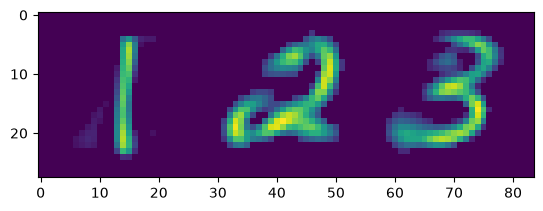

In [64]:
plt.imshow(dij.gen_cut("123"))

In [65]:
dij.get_param()

{0: ({'algorithm': 'auto',
   'atol': 0,
   'bandwidth': np.float64(158.6206896551724),
   'breadth_first': True,
   'kernel': 'gaussian',
   'leaf_size': 40,
   'metric': 'euclidean',
   'metric_params': None,
   'rtol': 0},
  {'copy': True,
   'iterated_power': 'auto',
   'n_components': 15,
   'n_oversamples': 10,
   'power_iteration_normalizer': 'auto',
   'random_state': None,
   'svd_solver': 'auto',
   'tol': 0.0,
   'whiten': False}),
 1: ({'algorithm': 'auto',
   'atol': 0,
   'bandwidth': np.float64(100.0),
   'breadth_first': True,
   'kernel': 'gaussian',
   'leaf_size': 40,
   'metric': 'euclidean',
   'metric_params': None,
   'rtol': 0},
  {'copy': True,
   'iterated_power': 'auto',
   'n_components': 15,
   'n_oversamples': 10,
   'power_iteration_normalizer': 'auto',
   'random_state': None,
   'svd_solver': 'auto',
   'tol': 0.0,
   'whiten': False}),
 2: ({'algorithm': 'auto',
   'atol': 0,
   'bandwidth': np.float64(172.41379310344826),
   'breadth_first': True,
   

In [69]:
import joblib

joblib.dump(dij,"mnist-creator.joblib")

['mnist-creator.joblib']

In [68]:
dij.gen("23").max()

np.float64(254.0)